In [186]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [187]:
import importnb
with importnb.Notebook():
    import EDA as eda

In [188]:
df=eda.final_df
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Country
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Yes,No,No,No,3,4.8,Dark Green,Excellent,314,Phillipines
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Yes,No,No,No,3,4.5,Dark Green,Excellent,591,Phillipines
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Yes,No,No,No,4,4.4,Green,Very Good,270,Phillipines
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,No,No,No,No,4,4.9,Dark Green,Excellent,365,Phillipines
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Yes,No,No,No,4,4.8,Dark Green,Excellent,229,Phillipines


In [189]:
# Missing Data Analysis
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                0
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
Country                 0
dtype: int64

In [190]:
df['Cuisines']=df['Cuisines'].fillna(df['Cuisines'].mode()[0])

In [191]:
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                0
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
Country                 0
dtype: int64

In [192]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes', 'Country'],
      dtype='object')

In [193]:
#Dropping the duplicate restaurants from the dataset
print(df.duplicated(subset=['Restaurant Name']).sum())
df=df.drop_duplicates(subset=['Restaurant Name'], keep='first')
print(df.duplicated(subset=['Restaurant Name']).sum())

2105
0


In [194]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes', 'Country'],
      dtype='object')

In [195]:
df_not_normalized=df
print(df_not_normalized[['Restaurant Name', 'Average Cost for two']])

               Restaurant Name  Average Cost for two
0             Le Petit Souffle                  1100
1             Izakaya Kikufuji                  1200
2       Heat - Edsa Shangri-La                  4000
3                         Ooma                  1500
4                  Sambo Kojin                  1500
...                        ...                   ...
9546              NamlÛ± Gurme                    80
9547             Ceviz AÛôacÛ±                   105
9548                     Huqqa                   170
9549              Aôôk Kahve                   120
9550  Walter's Coffee Roastery                    55

[7446 rows x 2 columns]


In [196]:
print(df.groupby(df['Country'])['Average Cost for two'].mean())

Country
Australia             24.083333
Brazil               133.965517
Canada                36.250000
India                636.761226
Indonesia         300277.777778
New Zealand           69.230769
Phillipines         1645.238095
Qatar                239.666667
Singapore            155.750000
South Africa         423.842105
Sri Lanka           2375.000000
Turkey                87.580645
UAE                  163.301887
United Kingdom        48.169014
United States         26.170213
Name: Average Cost for two, dtype: float64


In [197]:
#Normalizeing the average cost of two people so the comparison of accross the countries are valid
df['Average Cost for two']=df['Average Cost for two']/df.groupby(df['Country'])['Average Cost for two'].transform('mean')

C:\Users\dhruv\AppData\Local\Temp\ipykernel_37852\243610294.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Average Cost for two']=df['Average Cost for two']/df.groupby(df['Country'])['Average Cost for two'].transform('mean')


In [198]:
df[['Country', 'Average Cost for two']]

,Country,Average Cost for two
0,Phillipines,0.668596
1,Phillipines,0.729378
2,Phillipines,2.431259
3,Phillipines,0.911722
4,Phillipines,0.911722
...,...,...
9546,Turkey,0.913444
9547,Turkey,1.198895
9548,Turkey,1.941068
9549,Turkey,1.370166


In [199]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes', 'Country'],
      dtype='object')

# Handling the outliers

In [200]:
# Using the interquartile range to identify the outliers in the dataset
Q1=df['Average Cost for two'].quantile(0.25)
Q3=df['Average Cost for two'].quantile(0.75)
IQR=Q3-Q1;
upperbound=Q3+1.5*IQR
lowerbound=Q1-1.5*IQR

outliers=df[(df['Average Cost for two']>upperbound) | (df['Average Cost for two']<lowerbound)]
print(outliers[['Country', 'Average Cost for two']])
print('Number of outliers:', outliers.shape[0])

           Country  Average Cost for two
2      Phillipines              2.431259
8      Phillipines              3.646889
40          Brazil              2.612613
59          Brazil              2.239382
66          Brazil              2.239382
...            ...                   ...
9433         Qatar              2.294854
9457  South Africa              3.633429
9464  South Africa              2.253198
9484  South Africa              7.573575
9526        Turkey              4.567219

[743 rows x 2 columns]
Number of outliers: 743


{'whiskers': [<matplotlib.lines.Line2D at 0x215a7382710>,
 'caps': [<matplotlib.lines.Line2D at 0x215a7382990>,
 'boxes': [<matplotlib.lines.Line2D at 0x215a73825d0>],
 'medians': [<matplotlib.lines.Line2D at 0x215a7382c10>],
 'fliers': [<matplotlib.lines.Line2D at 0x215a7382d50>],
 'means': []}

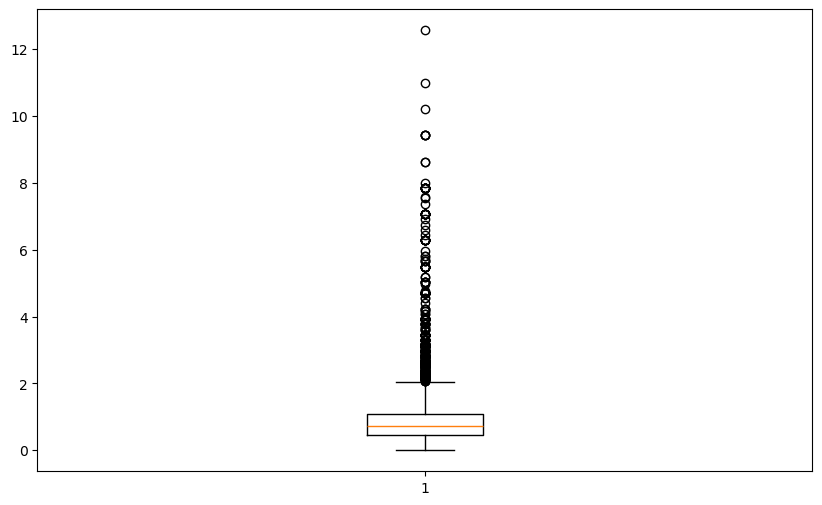

In [201]:
# Visualizing the outliers in the dataset using boxplot
plt.figure(figsize=(10, 6))
plt.boxplot(df['Average Cost for two'])

### Observation:
From the above result we can observe that there are so many outliers in the Average Cost for two, and from the result we have got from the IQR method also says that the outliers that we are getting are not because of Data entry or null values, it is because of the dataset it self, in dataset it contains the data for the different countries so that the currency of all the countries differ and the ppp(purchasing power parity) also differs in all the countries, so we are not able to remove this outliers niether can impute or manipulate them for the further analysis. So, in solution for this we have decided for further analysis we analysing the data for the 1 country India for now, means we doing the country specific analysis.

In [202]:
# Creating the dataframe which contain only the data of country India
df_india=df[df['Country']=='India']
df_india['Average Cost for two']=df['Average Cost for two']*636.761226
print(df_india)
print(df_india.shape)
print(df_india[['Restaurant Name', 'Average Cost for two']])

      Restaurant ID                        Restaurant Name  Country Code  \
624         3400025                             Jahanpanah             1   
625         3400341                    Rangrezz Restaurant             1   
626         3400005                Time2Eat - Mama Chicken             1   
627         3400021  Chokho Jeeman Marwari Jain Bhojanalya             1   
628         3400017                         Pinch Of Spice             1   
...             ...                                    ...           ...   
9271        2800100                               D Cabana             1   
9272        2800418                               Kaloreez             1   
9273        2800881                                Plot 17             1   
9274        2800042                       Vista - The Park             1   
9275        2800019               Flying Spaghetti Monster             1   

       City                                            Address  \
624    Agra  E 23, Sh

C:\Users\dhruv\AppData\Local\Temp\ipykernel_37852\1386548194.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_india['Average Cost for two']=df['Average Cost for two']*636.761226


In [203]:
df_india[df_india['Average Cost for two']==0]

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Country
634,3400073,The Latitude - Radisson Blu,1,Agra,"Radisson Blu, Taj East Gate Road, Tajganj, Agra","Radisson Blu, Tajganj","Radisson Blu, Tajganj, Agra",78.057044,27.163303,"North Indian, Chinese, Continental",...,No,No,No,No,1,3.9,Yellow,Good,103,India
637,3400346,Sheroes Hangout,1,Agra,"Opposite The Gateway Hotel, Fatehabad Road, Ta...",Tajganj,"Tajganj, Agra",78.040165,27.161850,"Cafe, North Indian, Chinese",...,No,No,No,No,1,4.9,Dark Green,Excellent,77,India
639,3400391,Chapter 1 Cafe,1,Agra,"1374 K/1375 K, 2nd floor, Dinesh Nagar, Fatehb...",Tajganj,"Tajganj, Agra",0.000000,0.000000,"Cafe, Italian, Mexican, North Indian, Continental",...,No,No,No,No,1,3.9,Yellow,Good,98,India
677,18317988,The BrewMaster,1,Allahabad,"Near Vishal Megamart, Civil Lines, Allahabad",Civil Lines,"Civil Lines, Allahabad",81.832796,25.451646,"North Indian, Chinese, Italian",...,No,No,No,No,1,3.3,Orange,Average,49,India
851,18279289,BMG - All Day Dining,1,Dehradun,"140 A, Rajpur Road, Jakhan, Dehradun",Jakhan,"Jakhan, Dehradun",78.068890,30.362686,"Chinese, North Indian, Fast Food",...,No,No,No,No,1,4.3,Green,Very Good,63,India
2364,2300497,Atmosphere Grill Cafe Sheesha,1,Kanpur,"8th Floor, J.S. Tower, 16/106 - Mall Road, Kan...",Mall Road,"Mall Road, Kanpur",80.354002,26.472001,"Indian, Chinese, Continental",...,No,No,No,No,1,3.6,Yellow,Good,34,India
2368,18312106,UrbanCrave,1,Kanpur,"14/125, The Mall, Mall Road, Colonelganj, Para...",Parade,"Parade, Kanpur",80.342796,26.474986,"Cafe, Continental, Desserts, Ice Cream, Italia...",...,No,No,No,No,1,3.9,Yellow,Good,127,India
9242,3900245,Deena Chat Bhandar,1,Varanasi,"D-47/184, Luxa Road, Dashaswmedh Road, Varanasi",Dashaswmedh Road,"Dashaswmedh Road, Varanasi",0.000000,0.000000,Street Food,...,No,No,No,No,1,3.8,Yellow,Good,78,India
9254,18246202,VNS Live Studio,1,Varanasi,"Hotel Varuna Ground Floor, 22 Gulab Bagh, Sigr...",Sigra,"Sigra, Varanasi",82.991694,25.318345,"Chinese, North Indian",...,No,No,No,No,1,3.5,Yellow,Good,109,India


### Obseravation:
We can see that, there are 9 rows which has average cost for two person is 0, which is not possible. So for the correct analysis we have to drop this rows.

In [204]:
df_india=df_india.drop(df_india[df_india['Average Cost for two']==0].index, axis=0)

In [205]:
df_india[df_india['Average Cost for two']==0]

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Country


In [206]:
# Now analsing the outlier with respect to the country India only again
# Using the interquartile range to identify the outliers in the dataset
Q1=df_india['Average Cost for two'].quantile(0.25)
Q3=df_india['Average Cost for two'].quantile(0.75)
IQR=Q3-Q1;
upperbound=Q3+1.5*IQR
lowerbound=Q1-1.5*IQR

outliers=df_india[(df_india['Average Cost for two']>upperbound) | (df_india['Average Cost for two']<lowerbound)]
print(outliers[['Country', 'Average Cost for two']])
print('Number of outliers:', outliers.shape[0])

     Country  Average Cost for two
629    India           2000.000001
630    India           2500.000001
631    India           2500.000001
633    India           3600.000002
638    India           1500.000001
...      ...                   ...
9212   India           1500.000001
9223   India           1500.000001
9260   India           1700.000001
9274   India           1500.000001
9275   India           1400.000001

[691 rows x 2 columns]
Number of outliers: 691


{'whiskers': [<matplotlib.lines.Line2D at 0x215a7376210>,
 'caps': [<matplotlib.lines.Line2D at 0x215a7376490>,
 'boxes': [<matplotlib.lines.Line2D at 0x215a73760d0>],
 'medians': [<matplotlib.lines.Line2D at 0x215a7376710>],
 'fliers': [<matplotlib.lines.Line2D at 0x215a7376850>],
 'means': []}

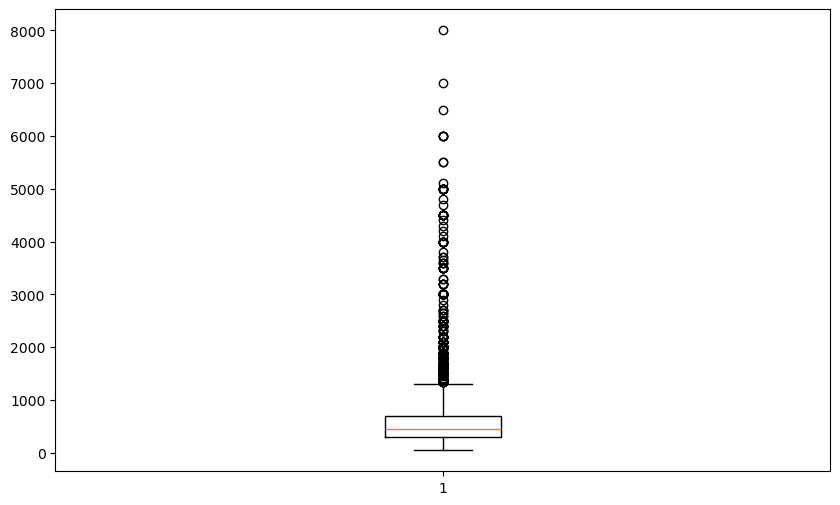

In [207]:
#Visualizing the outliers using boxplot
plt.figure(figsize=(10, 6))
plt.boxplot(df_india['Average Cost for two'])

### Observation:
After filtering the dataset for India only, we ran the IQR method on the 'Average Cost for two' column and found 691 outliers, which is 10.48% of the Indian restaurants.

From the analysis we found that these outliers are not because of data entry errors or missing values, but they are the premium/luxury segment of restaurants, mostly located in metro cities like New Delhi (391), Gurgaon (149), Noida (39). Some examples are Peshawri - ITC Mughal, Taj Bano - ITC Mughal, Dawat-e-Nawab - Radisson Blu, Bon Barbecue, Patang - The Revolving Restaurant, etc.

Also, the average rating of these outliers (3.62) is higher than the average rating of all the Indian restaurants (2.46), which confirms that these are the high-end premium restaurants which are also highly rated.

So, we have decided to keep this data as it is. Removing these outliers would remove the premium segment of restaurants and would bias our further analysis, as these are genuine data points and not errors.

In [208]:
# Saving the cleaned data in to a new csv file
os.makedirs('Output', exist_ok=True)
df_india.to_csv('Output/df_india_cleaned', index=False)